## <img src="logo_UNSAM.jpg" align="right" width="300" height="300"> *Análisis y precesamiento de señales*  
<h3 style="font-weight: normal;">Alumno: Joaquín Rios</h3>
&nbsp;
&nbsp;

## |  Trabajo Semanal N°4




### | Introducción

&emsp; En el trabajo anterior vimos el fenómeno de **leakage** o derramamiento espectral: cuando la frecuencia de la señal cae entre un bin y su consecutivo, es decir, por fuera de los múltiplos de la resolución espectral, la energía deja de concentrarse en un solo bin y se derrama sobre los vecinos. En este trabajo vamos a profundizar en ese efecto, pero mirando cómo afecta a los estimadores de amplitud y de frecuencia, y cómo cambia según la ventana que se utilice.

Para eso vamos a trabajar con una senoidal CON ruido cuya frecuencia es:

$$\Omega_1 = \Omega_0 + f_r \cdot \frac{2\pi}{N}, \qquad \Omega_0 = \frac{\pi}{2}$$

El factor $f_r$ es el parámetro más importante, ya que me define cuántos bins me desplazo respecto de $\Omega_0$. Como es una variable aleatoria uniforme entre $-2$ y $2$, en cada realización vamos a tener un grado distinto de leakage.

Además, tomaremos el parámetro $a_1$ como factor determinante de la potencia de la señal. Lo calibramos para que la senoidal tenga potencia unitaria:

$$P_x = \frac{a_1^2}{2} = 1\,\text{W} \;\Rightarrow\; a_1 = \sqrt{2}$$

De esta manera la varianza del ruido queda fijada directamente por la relación señal a ruido:

$$\sigma^2 = \frac{P_x}{SNR} = 10^{-\,SNR_{dB}/10} \quad \Rightarrow \quad \sigma^2 \approx 0{,}50 \;(3\,\text{dB}), \qquad \sigma^2 = 0{,}1 \;(10\,\text{dB})$$

Los demás parámetros se mantienen igual que en las TS anteriores: 200 realizaciones de 1000 muestras cada una, teniendo finalmente una matriz de resultados de esos tamaños.

Vamos a comparar cuatro ventanas: rectangular, flattop, blackmanharris y Taylor. Para cada una se estimará la amplitud y la frecuencia, y se analizará el sesgo y la varianza de cada estimador.

### | Desarrollo experimental
&emsp; Se creará primeramente la senoidal y la matriz de 1000 muestras con un $SNR = 10dB$ y luego un  $SNR = 3dB$ , teniendo 200 realizaciones distintas de acuerdo con los 200 valores distintos o iguales que puede tomar el vector ruido $f_r$ 
#### -> SNR = 10 dB

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import blackmanharris, flattop, hamming
from scipy.fft import fft, fftfreq

N=1000
CR = 200
vmax = np.sqrt(2)
fr=np.random.uniform(-2,2,CR)
o0= (np.pi)/2
ff=(o0) + fr *((2*np.pi)/N)
fs = 1000
nn = np.arange(N)

pr= 0.1
#Hago el broadcast de los vectores nn y ff

nn = nn.reshape(-1, 1)         # aseguramos que sea columna (4,1)
nn = np.tile(nn, (1, CR))

ff= np.tile(ff, (N, 1)) #Repito el vector ff en CR filas

xx = vmax * np.sin(ff*(nn))
tt = np.arange(0, N) / fs

sigma = np.sqrt(pr) #La desviación estándar del ruido normal es la raiz de la potencia
rr = np.random.normal(0,sigma,size=((N,CR)))

zz= xx+rr #Ya tengo las senoidales con el ruido

&emsp; Una vez que tenemos las senoidales de distinta frecuencia pasamos a analizarlas en el dominio de la frecuencia justamente. Para analizarlas veremos las 4 ventanas por separada, ya que al intentar plottear los 4 espectros al mismo tiempo veremos un "manchón" de colores y no se podrá apreciar bien las diferencias entre ellas. Además se mantuvo el eje X igual en todas, pero el eje Y se cambió de escala en cada una, por lo que no tienen la misma referencia ni el mismo máximo todas. Luego se pasarán a mostrar los histogramas de los estimadores de amplitud y de frecuencia.

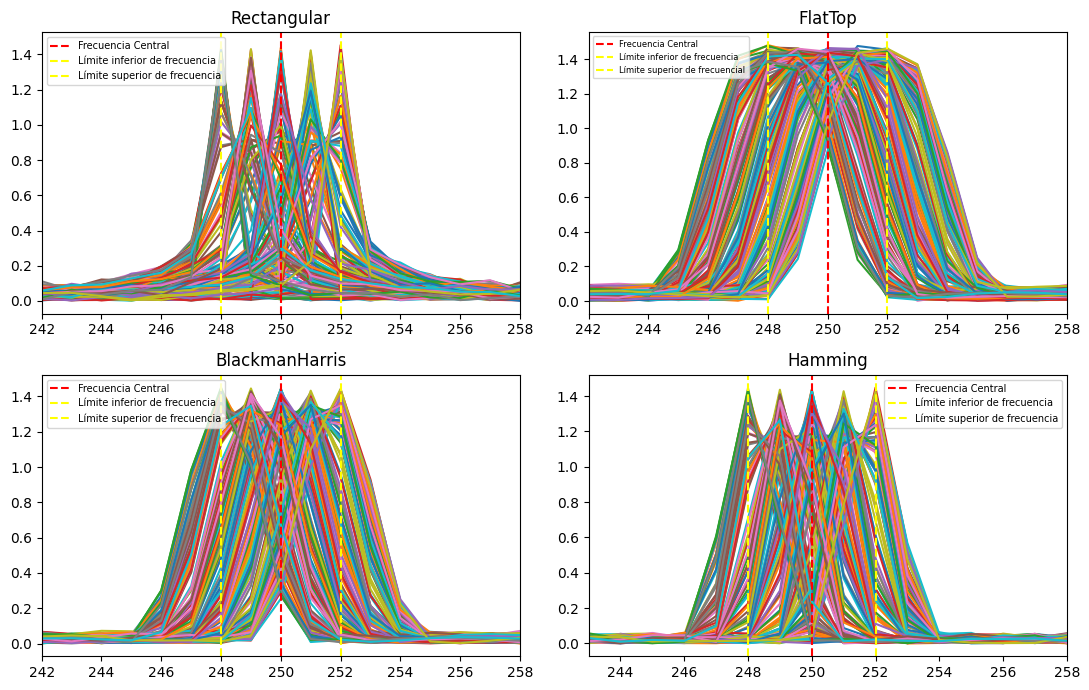

In [33]:
#Ventaneo con Rectangular!!!!!!
WR = np.ones((CR, N))
WR = np.rot90(WR,1,(0,1))

zzwr = WR*zz
fftzzwr = fft(zzwr,axis= 0) *(2/np.sum(WR[:, 0]))
fftzzwr = fftzzwr[:N//2]
fftzzwr_abs = np.abs(fftzzwr) 

#Ventaneo con BlackmanHarris!!!
WBH = blackmanharris(N, sym=False)
WBH = WBH.reshape(-1, 1) 
WBH = np.tile(WBH, (1, CR))

zzwbh = WBH*zz
fftzzbh = fft(zzwbh,axis= 0) * (2/np.sum(WBH[:, 0]))
fftzzbh = fftzzbh[:N//2]
fftzzbh_abs = np.abs(fftzzbh) 

#Ventaneo con FlatTop!!!
WFT = flattop(N, sym=False)
WFT = WFT.reshape(-1, 1) 
WFT = np.tile(WFT, (1, CR))

zzwft = WFT*zz
fftzzft = fft(zzwft,axis= 0) * (2/np.sum(WFT[:, 0]))
fftzzft = fftzzft[:N//2]
fftzzft_abs = np.abs(fftzzft) 

#Ventaneo con Hamming!!!
WH = hamming(N, sym=False)
WH = WH.reshape(-1, 1) 
WH = np.tile(WH, (1, CR))

zzwh = WH*zz
fftzzh = fft(zzwh,axis= 0) * (2/np.sum(WH[:, 0]))
fftzzh = fftzzh[:N//2]
fftzzh_abs = np.abs(fftzzh) 

freq = fftfreq(N,1/fs)
freq = freq[:N//2]

fig, axs = plt.subplots(2, 2, figsize=(11, 7))

axs[0,0]   # arriba izquierda
axs[0,1]   # arriba derecha
axs[1,0]   # abajo izquierda
axs[1,1]   # abajo derecha

axs[0,0].plot(freq, fftzzwr_abs)
axs[0,0].set_title("Rectangular")
axs[0,0].set_xlim(242, 258)
axs[0,0].axvline(x=250, color='red', linestyle='--', label="Frecuencia Central")
axs[0,0].axvline(x=248, color='yellow', linestyle='--', label="Límite inferior de frecuencia")
axs[0,0].axvline(x=252, color='yellow', linestyle='--', label="Límite superior de frecuencia")
axs[0,0].legend(fontsize=7) 

axs[0,1].plot(freq, fftzzft_abs)
axs[0,1].set_xlim(242, 258)
axs[0,1].set_title("FlatTop")
axs[0,1].axvline(x=250, color='red', linestyle='--', label="Frecuencia Central")
axs[0,1].axvline(x=248, color='yellow', linestyle='--', label="Límite inferior de frecuencia")
axs[0,1].axvline(x=252, color='yellow', linestyle='--', label="Límite superior de frecuencial")
axs[0,1].legend(fontsize=6) 

axs[1,0].plot(freq, fftzzbh_abs)
axs[1,0].set_xlim(242, 258)
axs[1,0].set_title("BlackmanHarris")
axs[1,0].axvline(x=250, color='red', linestyle='--', label="Frecuencia Central")
axs[1,0].axvline(x=248, color='yellow', linestyle='--', label="Límite inferior de frecuencia")
axs[1,0].axvline(x=252, color='yellow', linestyle='--', label="Límite superior de frecuencia")
axs[1,0].legend(fontsize=7) 

axs[1,1].plot(freq, fftzzh_abs)
axs[1,1].set_xlim(243, 258)
axs[1,1].set_title("Hamming")
axs[1,1].axvline(x=250, color='red', linestyle='--', label="Frecuencia Central")
axs[1,1].axvline(x=248, color='yellow', linestyle='--', label="Límite inferior de frecuencia")
axs[1,1].axvline(x=252, color='yellow', linestyle='--', label="Límite superior de frecuencia")
axs[1,1].legend(fontsize=7) 

plt.tight_layout()
plt.show()


&emsp; Acá se aprecia como actúa cada ventana por separada, donde lo más notable es el ancho de la ventana, y la agresividad de la misma, esto debido a que cada una tiene un ancho determinado por la resolución espectral de mi señal, refiriéndonos al ancho como el largo de mi lóbulo principal. La agresividad de la ventana es un parámetro que refiere a la diferencia de magnitudes entre el pico del lóbulo principal y el pico del primer lóbulo secundario que aparece.

&emsp; Observamos como la amplitud de la señal varía de acuerdo a qué ventana estemos utilizando, y esto es debido a la propia definición de la *DFT*, ya que si utilizamos la ventana rectangular (como si no hiciesemos nada) estamos sumando todo los factroes $w[n]$  "completos", pero al utilizar otra ventana estamos o dejando afuera ciertos valores de la DFT o atenuándolos, lo que implica una disminución de la amplitdud, a esto se lo conoce como **ganancia coherente**, un valor entre *1 y 0*, el cual tiene cada ventana en particular.

&emsp; En base a esto vamos a clasificar cada una de las ventanas. Primero vemos como la FlatTop claramente es la ventana más agresiva, teniendo una **GH** muy baja y un lóbulo principal muy ancho, pero a favor de qué los lóbulos secundarios tienen una ganancia mucho menor, por lo que este tipo de ventana atenua muy bien ganancias parásitas de una señal que no estén "cercanas" al ancho de mi lóbulo principal. El problema es cuando queremos distinguir dos ventanas que en términos de la resolución espectral estén relativamente cerca, en este caso debemos ver si la altura de mi lóbulo la "tapa". La peor (depende para qué estemos utilizándoa) en este caso sería la rectangular, donde vemos claramente como sobresalen los lóbulos secundarios, teniendo un derramamiento espectral considerablemente alto, algo que aplicando el ventaneo no sucede, los demás espectros tienen una amplitud del derramamiento inferior a $0.05$ . Lo positivo de esta ventana es que el ancho del lóbulo principal es considerablemente bajo, pero otras ventanas tiene uno similar mejorando este problema del derramaiento.
&emsp;&emsp; 


&emsp; Ahora vamos a tomar un único estimador $ \hat a_1 $ en una frecuencia determinada, la cual será la frecuencia correspondiente al parámetro  $\Omega_0$, es decir la frecuecia donde debería estar la senoidal verdaderente, aunque para tener una estimación  más acertada deberíamos hacer un promedio con los bins donde puede llegar a caer la senoide. Además haremos un esimador de la frecuencia, ya que ccomo planteamos al inicio esta varía con cada realización. Para compararlas haremos 2 histogramas.

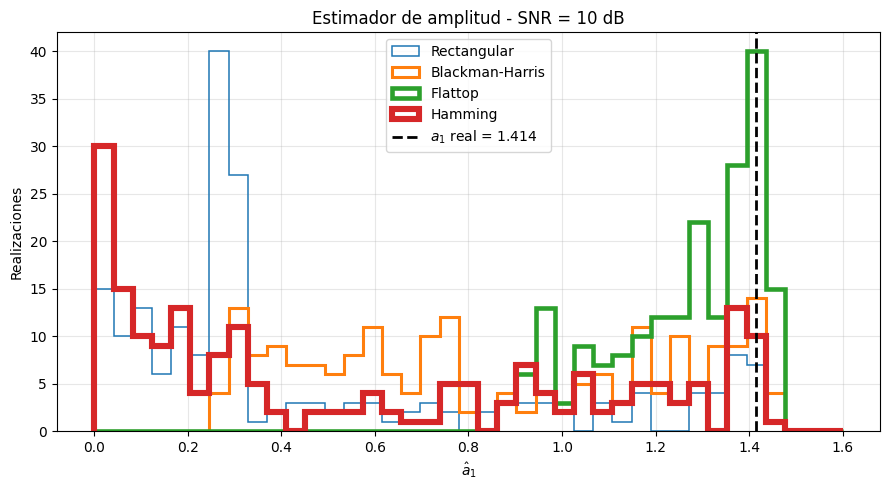

In [34]:
Omega = freq * (2 * np.pi / fs) #Paso a omega para calcular más fácil
a0 = vmax

#Estimadores para ventana Rectangular 

binMax1 =  np.argmax(fftzzwr_abs, axis=0)
Omega_estimadaWR= Omega[binMax1]
sesgoOmegaWR = np.mean(Omega_estimadaWR - ff[0, :])
varOmegaWR = np.var(Omega_estimadaWR)

Vector_a1WR =fftzzwr_abs[N//4,:]
a1WR = (Vector_a1WR.sum())/CR

sesgo_a1WR = a1WR - a0
var_a1WR = np.var(Vector_a1WR)

#Estimadores para ventana BlackmanHarris 

binMax2 =  np.argmax(fftzzbh_abs, axis=0)
Omega_estimadaBH = Omega[binMax2]
sesgoOmegaBH = np.mean(Omega_estimadaBH - ff[0, :])
varOmegaBH = np.var(Omega_estimadaBH)

Vector_a1BH =fftzzbh_abs[N//4,:]
a1BH = (Vector_a1BH.sum())/CR

sesgo_a1BH = a1BH - a0
var_a1BH = np.var(Vector_a1BH)

#Estimadores para ventana Flattop

binMax3 =  np.argmax(fftzzft_abs, axis=0)
Omega_estimadaFT = Omega[binMax3]
sesgoOmegaFT = np.mean(Omega_estimadaFT - ff[0, :])
varOmegaFT = np.var(Omega_estimadaFT)

Vector_a1FT =fftzzft_abs[N//4,:]
a1FT = (Vector_a1FT.sum())/CR

sesgo_a1FT = a1FT - a0
var_a1FT = np.var(Vector_a1FT)

#Estimadores para ventana Hamming

binMax4 =  np.argmax(fftzzh_abs, axis=0)
Omega_estimadaH = Omega[binMax4]
sesgoOmegaH = np.mean(Omega_estimadaH - ff[0, :])
varOmegaH = np.var(Omega_estimadaH)

Vector_a1H =fftzzh_abs[N//4,:]
a1H = (Vector_a1H.sum())/CR

sesgo_a1H = a1H - a0
var_a1H = np.var(Vector_a1H)

amp = {
    'Rectangular':   Vector_a1WR,
    'Blackman-Harris': Vector_a1BH,
    'Flattop':       Vector_a1FT,
    'Hamming':       Vector_a1H,
}

bins = np.linspace(0, 1.6, 40)

plt.figure(figsize=(9, 5))

i= 0

for nombre, vec in amp.items():
    i = i+1.1
    plt.hist(
        vec,
        bins=bins,
        histtype='step',
        linewidth=i,
        label=nombre
    )

plt.axvline(
    a0,
    color='black',
    linestyle='--',
    linewidth=2,
    label=fr'$a_1$ real = {a0:.3f}'
)

plt.xlabel(r'$\hat{a}_1$')
plt.ylabel('Realizaciones')
plt.title('Estimador de amplitud - SNR = 10 dB')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

&emsp; En el histograma del estimador de amplitud se aprecia que el comportamiento de cada ventana está dominado por la forma de su lóbulo principal y no tanto por el ruido. Como la frecuencia real de la senoidal es $\Omega_1 = \Omega_0 + f_r\frac{2\pi}{N}$ con $f_r \in (-2, 2)$, la señal cae hasta dos bins por fuera de $\Omega_0$, que es donde evaluamos el estimador $\hat{a}_1$. Esto significa que lo que realmente medimos es cuánto "ve" cada ventana a una componente que no está exactamente donde miramos, y eso depende directamente de la respuesta en frecuencia de la ventana.

&emsp; La **ventana flattop** es la que mejor estima la amplitud, su histograma se concentra alrededor del valor real $a_1=\sqrt{2}\approx1.414$, con un sesgo pequeño y una varianza baja. Esto es consecuencia de que su lóbulo principal es muy ancho y casi plano, por lo que el módulo de la DFT apenas cambia aunque la frecuencia se corra uno o dos bins. Lo que se paga es la resolución espectral, ya que ese mismo ancho hace que sea la peor para distinguir frecuencias cercanas, y por eso su ventaja aparece en amplitud pero no necesariamente en frecuencia.

&emsp; La **ventana rectangular** es la más sensible a la desviación de frecuencia. Su lóbulo principal es angosto y su respuesta tiene la forma de un $\text{sinc}$, con ceros en $\delta=\pm1,\pm2$ bins. Cuando $f_r$ cae cerca de esos valores el estimador da casi cero (solo queda el ruido), y en los valores intermedios da magnitudes parciales, por eso el histograma se desparrama entre 0 y 1.41, con un sesgo grande y una varianza grande. Es importante notar que esa dispersión es sistemática, porque viene de la dependencia con $f_r$ y no de la aleatoriedad del ruido.

&emsp; Las **ventanas Hamming y Blackman-Harris** tienen un comportamiento intermedio, su lóbulo principal es más ancho que el de la rectangular pero no es plano, por lo que siguen atenuando la amplitud cuando la señal se aleja de $\Omega_0$. Los histogramas quedan desparramados y con sesgo negativo, mejores que la rectangular en algunos casos pero claramente peores que la flattop. En Hamming se observa además una acumulación de realizaciones cerca de cero, ya que su lóbulo principal tiene un cero en $\delta=\pm2$ y los casos con $f_r$ cercano a $\pm2$ caen justo ahí.

#### -> SNR = 3 dB
&emsp; Ahora usamos los mismo códigos pero para una potencia de ruido mayor (OSea un SNR menor al anterior).

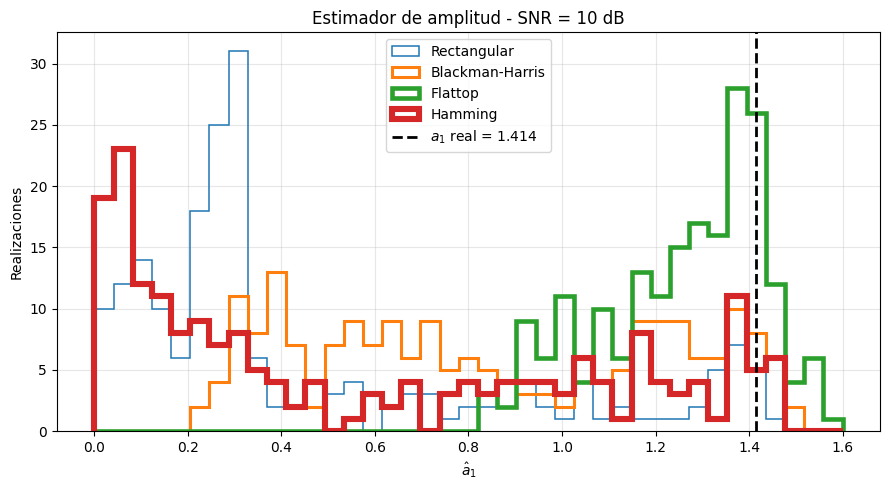

In [35]:
pr= 0.501
sigma = np.sqrt(pr) #La desviación estándar del ruido normal es la raiz de la potencia
rr = np.random.normal(0,sigma,size=((N,CR)))

zz= xx+rr #Ya tengo las senoidales con el ruido

#Ventaneo con Rectangular!!!!!!
WR = np.ones((CR, N))
WR = np.rot90(WR,1,(0,1))

zzwr = WR*zz
fftzzwr = fft(zzwr,axis= 0) *(2/np.sum(WR[:, 0]))
fftzzwr = fftzzwr[:N//2]
fftzzwr_abs = np.abs(fftzzwr) 

#Ventaneo con BlackmanHarris!!!
WBH = blackmanharris(N, sym=False)
WBH = WBH.reshape(-1, 1) 
WBH = np.tile(WBH, (1, CR))

zzwbh = WBH*zz
fftzzbh = fft(zzwbh,axis= 0) * (2/np.sum(WBH[:, 0]))
fftzzbh = fftzzbh[:N//2]
fftzzbh_abs = np.abs(fftzzbh) 

#Ventaneo con FlatTop!!!
WFT = flattop(N, sym=False)
WFT = WFT.reshape(-1, 1) 
WFT = np.tile(WFT, (1, CR))

zzwft = WFT*zz
fftzzft = fft(zzwft,axis= 0) * (2/np.sum(WFT[:, 0]))
fftzzft = fftzzft[:N//2]
fftzzft_abs = np.abs(fftzzft) 

#Ventaneo con Hamming!!!
WH = hamming(N, sym=False)
WH = WH.reshape(-1, 1) 
WH = np.tile(WH, (1, CR))

zzwh = WH*zz
fftzzh = fft(zzwh,axis= 0) * (2/np.sum(WH[:, 0]))
fftzzh = fftzzh[:N//2]
fftzzh_abs = np.abs(fftzzh) 

#Estimadores para ventana Rectangular 

binMax1 =  np.argmax(fftzzwr_abs, axis=0)
Omega_estimadaWR= Omega[binMax1]
sesgoOmegaWR = np.mean(Omega_estimadaWR - ff[0, :])
varOmegaWR = np.var(Omega_estimadaWR)

Vector_a1WR =fftzzwr_abs[N//4,:]
a1WR = (Vector_a1WR.sum())/CR

sesgo_a1WR = a1WR - a0
var_a1WR = np.var(Vector_a1WR)

#Estimadores para ventana BlackmanHarris 

binMax2 =  np.argmax(fftzzbh_abs, axis=0)
Omega_estimadaBH = Omega[binMax2]
sesgoOmegaBH = np.mean(Omega_estimadaBH - ff[0, :])
varOmegaBH = np.var(Omega_estimadaBH)

Vector_a1BH =fftzzbh_abs[N//4,:]
a1BH = (Vector_a1BH.sum())/CR

sesgo_a1BH = a1BH - a0
var_a1BH = np.var(Vector_a1BH)

#Estimadores para ventana Flattop

binMax3 =  np.argmax(fftzzft_abs, axis=0)
Omega_estimadaFT = Omega[binMax3]
sesgoOmegaFT = np.mean(Omega_estimadaFT - ff[0, :])
varOmegaFT = np.var(Omega_estimadaFT)

Vector_a1FT =fftzzft_abs[N//4,:]
a1FT = (Vector_a1FT.sum())/CR

sesgo_a1FT = a1FT - a0
var_a1FT = np.var(Vector_a1FT)

#Estimadores para ventana Hamming

binMax4 =  np.argmax(fftzzh_abs, axis=0)
Omega_estimadaH = Omega[binMax4]
sesgoOmegaH = np.mean(Omega_estimadaH - ff[0, :])
varOmegaH = np.var(Omega_estimadaH)

Vector_a1H =fftzzh_abs[N//4,:]
a1H = (Vector_a1H.sum())/CR

sesgo_a1H = a1H - a0
var_a1H = np.var(Vector_a1H)

amp = {
    'Rectangular':   Vector_a1WR,
    'Blackman-Harris': Vector_a1BH,
    'Flattop':       Vector_a1FT,
    'Hamming':       Vector_a1H,
}

bins = np.linspace(0, 1.6, 40)

plt.figure(figsize=(9, 5))

i= 0

for nombre, vec in amp.items():
    i = i+1.1
    plt.hist(
        vec,
        bins=bins,
        histtype='step',
        linewidth=i,
        label=nombre
    )

plt.axvline(
    a0,
    color='black',
    linestyle='--',
    linewidth=2,
    label=fr'$a_1$ real = {a0:.3f}'
)

plt.xlabel(r'$\hat{a}_1$')
plt.ylabel('Realizaciones')
plt.title('Estimador de amplitud - SNR = 10 dB')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

&emsp; Al bajar el SNR (en este caso a 3 dB) aumenta la potencia del ruido, de $0.1$ W a $\approx0.5$ W. Este ruido se suma en cada bin de la DFT y agrega una componente aleatoria al módulo, por lo que la varianza de todos los estimadores aumenta y los histogramas se ensanchan. Además, como se toma el módulo del espectro, el ruido siempre suma de forma positiva, lo que puede introducir un pequeño sesgo hacia arriba, sobre todo en los casos donde la amplitud estimada es cercana a cero (rectangular y Hamming en los ceros del lóbulo).

&emsp; También influye la ganancia de procesamiento de cada ventana: el ruido blanco se reparte entre todos los bins, pero ventanas con menor ganancia coherente, como flattop, atenúan la señal y el ruido de forma distinta, y su ancho de banda equivalente de ruido es mayor. Por eso el efecto del ruido no es igual para todas.

&emsp; Por el contrario, el sesgo debido a la fuga espectral (la forma del lóbulo principal) no depende del SNR, ya que viene de la ventana y de la desviación $f_r$. Por lo tanto, al cambiar el SNR el orden relativo entre ventanas debería mantenerse (flattop mejor que el resto en amplitud), y lo que cambia principalmente es el ancho de los histogramas. A 10 dB el sesgo sistemático domina sobre el ruido, y a 3 dB el ruido empieza a competir con él, aunque la diferencia entre ventanas seguiría siendo visible.

#### Tabla de Estimadores (SNR = 10 dB)

| Ventana | Sesgo Amplitud ($s_a$) | Varianza Amplitud ($v_a$) | Sesgo Frecuencia ($s_\Omega$) | Varianza Frecuencia ($v_\Omega$) |
|---|---|---|---|---|
| Rectangular | -0.967461 | 0.183751 | -0.000132 | 0.000070 |
| Flattop | -0.144448 | 0.026474 | -0.000226 | 0.000072 |
| Blackman-Harris | -0.548628 | 0.142796 | -0.000100 | 0.000070 |
| Hamming | -0.922451 | 0.242728 | -0.000132 | 0.000070 |

#### Tabla de Estimadores (SNR = 3 dB)

| Ventana | Sesgo Amplitud ($s_a$) | Varianza Amplitud ($v_a$) | Sesgo Frecuencia ($s_\Omega$) | Varianza Frecuencia ($v_\Omega$) |
|---|---|---|---|---|
| Rectangular | -0.877756 | 0.230148 | 0.000231 | 0.000059 |
| Flattop | -0.122839 | 0.024449 | -0.000020 | 0.000060 |
| Blackman-Harris | -0.488283 | 0.145066 | 0.000231 | 0.000060 |
| Hamming| -0.830734 | 0.276780 | 0.000231 | 0.000059 |





### | Conclusiones
  En esta TS se observó cómo las ventanas rectangular, flattop, Blackman-Harris y Hamming afectan a los estimadores de amplitud y de frecuencia de una senoidal con ruido, usando 200 realizaciones por SNR. Como la frecuencia real se desvía hasta dos bins de $\Omega_0$, el sesgo de la amplitud dependió casi por completo del leakage, es decir, de la forma del lóbulo principal de cada ventana. La rectangular fue la más sensible (respuesta tipo $\text{sinc}$, histograma muy disperso entre 0 y $\sqrt{2}$), mientras que la flattop fue la mejor, concentrándose cerca de $a_1\approx1.414$ gracias a su lóbulo ancho y plano. Hamming y Blackman-Harris quedaron en un punto intermedio. Fue necesario normalizar por la ganancia coherente ($\sum w$) para que las ventanas fueran comparables.

  Al bajar el SNR de 10 a 3 dB aumenta la potencia del ruido y con ella la varianza de todos los estimadores, ensanchando los histogramas. El sesgo por leakage no cambia, porque depende de la ventana y no del ruido, por lo que el orden entre ventanas se mantiene.

  Para estimar amplitud conviene la flattop, que sacrifica resolución a cambio de ser casi insensible a la desviación de frecuencia. Para estimar frecuencia o separar componentes cercanas conviene una ventana de lóbulo angosto, como la rectangular, aceptando más leakage. Hamming y Blackman-Harris son un compromiso.

  Por último, bajar la varianza puede ser más útil que bajar el sesgo, un sesgo sistemático y conocido se puede corregir, pero la dispersión aleatoria no. Como en la práctica se dispone de una sola realización, es preferible un estimador algo sesgado pero repetible (flattop) a uno poco sesgado pero muy disperso.